In [33]:
%pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 314.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 293.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from pathlib import Path
from pyspark.sql import SparkSession
##import h5py
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Matplotlib created a temporary cache directory at /scratch/dmoncivais/job_46665272/matplotlib-s1jem3sm because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
out_dir = Path(f"/expanse/lustre/projects/uci157/{os.environ['USER']}/stead")
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Downloading to: {out_dir}")

In [3]:
path = kagglehub.dataset_download("isevilla/stanford-earthquake-dataset-stead", output_dir = str(out_dir))

print("Path to dataset files:", path)

100%|██████████| 79.3G/79.3G [08:51<00:00, 160MB/s]   

Extracting files...


Path to dataset files: /expanse/lustre/projects/uci157/dmoncivais/stead


In [3]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "10g") \
    .config('spark.executor.instances', 15) \
    .getOrCreate()

In [4]:
df = spark.read.csv(f"{out_dir}/merge.csv", header = True)
print(type(df))

<class 'pyspark.sql.dataframe.DataFrame'>


In [5]:
print(f"Number of rows: {df.count()}\n")

print("Description of the data set:")
df.describe().show()

print("Data frame schema:")
df.printSchema()

print(f"Top 100 receivers based on count of readings: (receiver_code | count)")
i = 0
for row in df.groupBy('receiver_code').count().sort('count', ascending=False).collect():
    print(f"{row['receiver_code']} | {row['count']}")
    i += 1
    if i == 100:
        break

print(f"\nTotal of unique values:\n\tUnique number of network codes:{df.select('network_code').distinct().count()}\n\tUnique number of receiver_code:{df.select('receiver_code').distinct().count()}\n\tUnique number of receiver_type:{df.select('receiver_type').distinct().count()}")

Number of rows: 1268314

Description of the data set:
+-------+--------------------+-----------------+------------------+------------------+--------------------+--------------------+-----------------+---------+--------------------+-----------------+-----------------+---------+-------------------+--------------------+--------------------+-----------------------------+-----------------+-------------------+----------------+--------------+--------------------------------+------------------+---------------------------+------------------+---------------------+-----------------------+--------------------------------+-------------------+------------------+------------------+--------------------+---------------+--------------------+----------------+--------------------+
|summary|        network_code|    receiver_code|     receiver_type| receiver_latitude|  receiver_longitude|receiver_elevation_m| p_arrival_sample| p_status|            p_weight|     p_travel_sec| s_arrival_sample| s_status|     

In [6]:
coordinates = df.select("receiver_latitude", "receiver_longitude")\
              .rdd.map(lambda x: (x[0], x[1]))
coords = coordinates.collect()

latitudes = []
longitudes = []
i = 0
for row in coords:
    try:
        longitudes.append(float(row[1]))
        latitudes.append(float(row[0]))
    except Exception as e:
        print(row)
        i += 1 
        if i == 5:
            break

('222.9', '[56.         58.09999847 55.40000153]')
('222.9', '[53.5        58.59999847 55.70000076]')
('136.7', '[44.5        49.20000076 42.40000153]')
('88.5', '[84.90000153 83.80000305 68.90000153]')
('187.7', '[32.29999924 27.5        28.60000038]')


In [22]:
len(longitudes), len(latitudes)

(235871, 235871)

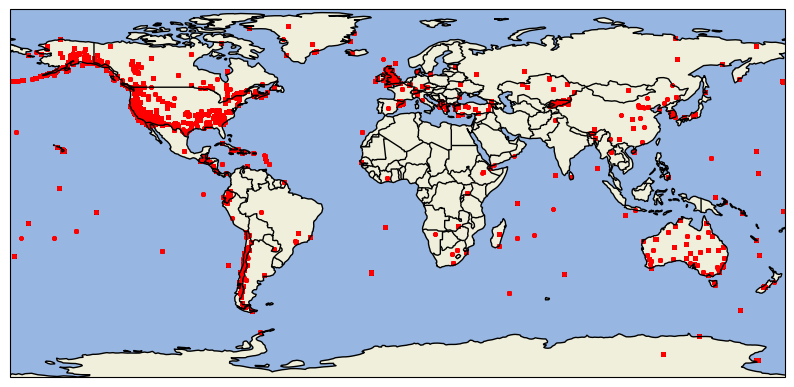

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

ax.scatter(longitudes, latitudes,
           s=5,
           transform=ccrs.PlateCarree(),
           color = 'red'
          )

plt.show()